In [1]:
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.integrate as integrate

%load_ext autoreload
%autoreload 2

from GP_code import simulate_population_single, get_mean_trajectory



In [2]:
def example_rates(t):
    # Example: rates depend on drug concentration
    l = 0.05 * np.sin(0.1 * t) + 0.1 # Birth rate
    mu = 0.08 # Death rate increases over time
    return l, mu

In [14]:
#True value: E[Z(t)]
import scipy.integrate as integrate

def func(t):
    return (0.05 * np.sin(0.1 * t) + 0.1) - 0.08

def func_sens(t):
    return np.exp(0.05/0.1 + (0.1-0.08)*t - (0.05/0.1)*np.cos(0.1*t)) * (0.05*np.sin(0.1 * t) + 0.1)


def calc_expectation(Z0, func, t):
    value, error = Z0 * np.exp(integrate.quad(func, 0, t))
    return value

def calc_cell_division(func_sens, t):
    '''
    Top right of page 183
    '''
    
    value, error = integrate.quad(func_sens, 0, t)
    return value



In [4]:
vals = np.linspace(0, 250, 250)
store = np.zeros(len(vals))
for i, _ in enumerate(vals):
    store[i] = calc_expectation(1, func, _)
    

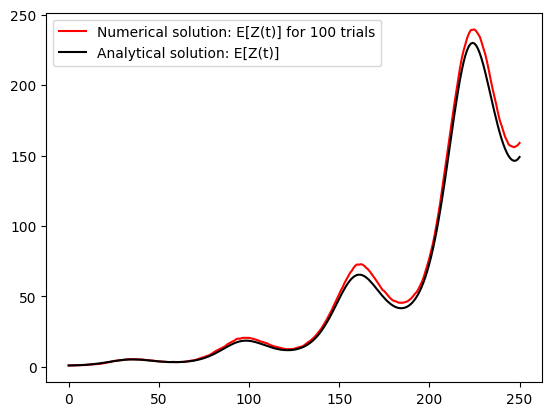

In [5]:
N = 100 #Number of trials
grid, mean_pop, mean_divs = get_mean_trajectory(N, 250, 1, example_rates, 0.3)
plt.plot(grid, mean_pop, c = 'red', label = f'Numerical solution: E[Z(t)] for {N} trials' )
plt.plot(vals, store, c = 'black', linestyle = '-', label = 'Analytical solution: E[Z(t)]')
plt.legend()

plt.show()

Fig 1 (b): birth-death rate over time

<Axes: >

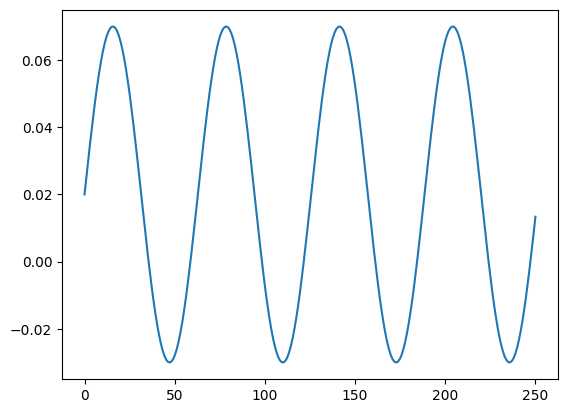

In [6]:
time = np.linspace(0, 250, 250)
y_axis = np.zeros(len(time))
for i, n in enumerate(time):
    y_axis[i] = func(n)

sns.lineplot(x = time, y = y_axis)

In [15]:
vals_c = np.linspace(0, 250, 250)
store_c = np.zeros(len(vals_c))
for i, _ in enumerate(vals_c):
    store_c[i] = calc_cell_division(func_sens, _)

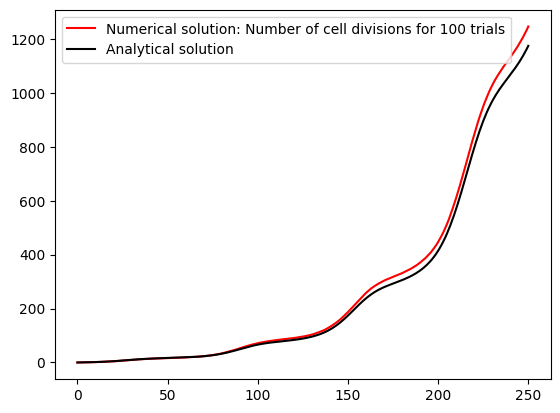

In [17]:
plt.plot(grid, mean_divs, c = 'red', label = f'Numerical solution: Number of cell divisions for {N} trials' )
plt.plot(vals_c, store_c, c = 'black', linestyle = '-', label = 'Analytical solution')
plt.legend()

plt.show()